<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/production/well_chemistry_and_water_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Well chemistry and water management with NeqSim

A compositional workflow for water saturation, condensation, separation, brine density, hydrate risk, and monoethylene glycol (MEG) inhibition in oil and gas production. The notebook is aimed at senior students and production, flow-assurance, and process engineers.

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim==3.16.0"])
from importlib.metadata import version
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neqsim import jneqsim
from neqsim.thermo import fluid, TPflash, hydt
from neqsim.process import clearProcess, stream, cooler, separator, runProcess
NEQSIM_VERSION = version("neqsim")
print(f"NeqSim {NEQSIM_VERSION}; Python {sys.version.split()[0]}")

NeqSim 3.16.0; Python 3.12.13


## Learning objectives, prerequisites, and scope

You should know phase equilibrium, mole and mass fractions, and steady-state balances. After completing the notebook you can: build a water-containing CPA fluid; calculate saturated-water content and water dew point; quantify liquid-water knock-out during cooling; evaluate moderate NaCl brine density; calculate hydrate equilibrium and MEG inhibition; and turn results into water-handling and chemical-dosing screens. This is a thermodynamic screening study, not a corrosion, scale-kinetics, water-treatment, or chemical-compatibility design.

In [2]:
basis = {
    "pressure_bara": 70.0, "saturation_temperature_C": 35.0,
    "cooler_outlet_C": 10.0, "dry_gas_flow_kg_per_h": 10_000.0,
    "minimum_hydrate_margin_K": 5.0, "moderate_brine_limit_wt_percent": 10.0
}
dry_gas_composition = {
    "nitrogen": 0.01, "CO2": 0.02, "methane": 0.86,
    "ethane": 0.07, "propane": 0.03, "n-butane": 0.01
}
assert abs(sum(dry_gas_composition.values()) - 1.0) < 1e-12
pd.Series(basis, name="value").to_frame()

,value
pressure_bara,70.0
saturation_temperature_C,35.0
cooler_outlet_C,10.0
dry_gas_flow_kg_per_h,10000.0
minimum_hydrate_margin_K,5.0
moderate_brine_limit_wt_percent,10.0


## Why water management is a production-system problem

Reservoir water, condensed water, injected water, and chemical-carrier water can create hydrates, corrosion, mineral scale, emulsions, and treatment loads. Gas water content is controlled by equality of water fugacity between phases. Cooling or pressure change may cross the water dew point and create a free aqueous phase. Water rate then propagates into separators, pumps, treatment equipment, disposal or reinjection, and chemical demand.

In [3]:
def make_dry_gas(temperature_C=35.0, pressure_bara=70.0, flow_kg_h=10_000.0):
    system = fluid("cpa")
    for component, fraction in dry_gas_composition.items():
        system.addComponent(component, fraction)
    system.setMixingRule(10)  # released CPA mixing rule used by NeqSim water examples
    system.setMultiPhaseCheck(True)
    system.setTemperature(temperature_C, "C")
    system.setPressure(pressure_bara, "bara")
    system.setTotalFlowRate(flow_kg_h, "kg/hr")
    return system
saturated_feed = make_dry_gas()
ops = jneqsim.thermodynamicoperations.ThermodynamicOperations(saturated_feed)
ops.saturateWithWater()
TPflash(saturated_feed)
saturated_feed.initProperties()
print(f"Saturated feed phases: {saturated_feed.getNumberOfPhases()}")

Saturated feed phases: 1


## How NeqSim performs the calculation

`fluid('cpa')` creates a cubic-plus-association thermodynamic system. CPA retains a cubic EOS description for hydrocarbons while adding association terms important for water and glycols. Components, mixing rule, state, and flow basis live in the thermodynamic system. `saturateWithWater()` adds water until the gas is at equilibrium with water at the specified state; `TPflash` then solves phase equilibrium. Process streams carry cloned thermodynamic states through connected unit operations.

In [4]:
water_ppm_mol = saturated_feed.getPhase("gas").getComponent("water").getx() * 1e6
water_feed_kg_h = saturated_feed.getPhase("gas").getComponent("water").getFlowRate("kg/hr")
saturated_state = pd.Series({
    "pressure [bara]": saturated_feed.getPressure("bara"),
    "temperature [degC]": saturated_feed.getTemperature("C"),
    "wet-gas flow [kg/h]": saturated_feed.getFlowRate("kg/hr"),
    "water in gas [mol ppm]": water_ppm_mol,
    "water carried by gas [kg/h]": water_feed_kg_h,
    "gas density [kg/m3]": saturated_feed.getDensity("kg/m3"),
}, name="saturated feed")
saturated_state.to_frame().round(5)

,saturated feed
pressure [bara],70.00000
temperature [degC],35.00000
wet-gas flow [kg/h],10009.63983
water in gas [mol ppm],1013.86159
water carried by gas [kg/h],9.63983
gas density [kg/m3],59.66015


## Water dew point

The water dew point is the temperature at which an infinitesimal aqueous phase becomes stable at fixed pressure and overall composition. The margin is $\Delta T_{wdp}=T_{operating}-T_{wdp}$. Positive margin means the state is warmer than the predicted dew point; negative margin means free water is thermodynamically possible. Because this feed was saturated at 35 °C and 70 bara, the 70-bara result provides a built-in limiting-case check.

In [5]:
dew_rows = []
for pressure in [30.0, 50.0, 70.0, 100.0, 130.0]:
    dew_fluid = saturated_feed.clone()
    dew_fluid.setPressure(pressure, "bara")
    dew_fluid.setTemperature(10.0, "C")
    dew_ops = jneqsim.thermodynamicoperations.ThermodynamicOperations(dew_fluid)
    dew_ops.waterDewPointTemperatureMultiphaseFlash()
    dew_rows.append({"pressure [bara]": pressure, "water dew point [degC]": dew_fluid.getTemperature("C")})
dew_point_table = pd.DataFrame(dew_rows)
dew_point_table.round(3)

,pressure [bara],water dew point [degC]
0,30.0,22.322
1,50.0,30.005
2,70.0,34.964
3,100.0,39.955
4,130.0,43.330


## Cooling and condensed-water load

At fixed pressure and total water inventory, cooling below the dew point transfers water from gas to the aqueous phase. For each flashed state, the water balance is $\dot m_{w,feed}=\dot m_{w,gas}+\dot m_{w,aqueous}$. Hydrocarbon and acid-gas dissolution means the liquid phase is not exactly pure water. The model reports both phase amount and composition rather than assuming a fixed condensation fraction.

In [6]:
cooling_rows = []
for temperature in [35.0, 30.0, 20.0, 10.0, 5.0, 0.0]:
    cooled = saturated_feed.clone()
    cooled.setTemperature(temperature, "C")
    TPflash(cooled)
    gas_water = cooled.getPhase("gas").getComponent("water").getFlowRate("kg/hr")
    aqueous_water = 0.0
    aqueous_total = 0.0
    if cooled.hasPhaseType("aqueous"):
        aqueous_water = cooled.getPhase("aqueous").getComponent("water").getFlowRate("kg/hr")
        aqueous_total = cooled.getPhase("aqueous").getFlowRate("kg/hr")
    cooling_rows.append({
        "temperature [degC]": temperature, "gas water [kg/h]": gas_water,
        "aqueous water [kg/h]": aqueous_water, "aqueous phase [kg/h]": aqueous_total,
        "gas water [mol ppm]": cooled.getPhase("gas").getComponent("water").getx()*1e6
    })
cooling_table = pd.DataFrame(cooling_rows)
cooling_table.round(4)

,temperature [degC],gas water [kg/h],aqueous water [kg/h],aqueous phase [kg/h],gas water [mol ppm]
0,35.0,9.6398,0.0000,0.0000,1013.8616
1,30.0,7.4057,2.2341,2.2394,779.0741
2,20.0,4.2379,5.4019,5.4169,445.9731
3,10.0,2.3329,7.3069,7.3312,245.5484
4,5.0,1.7042,7.9357,7.9648,179.3848
5,0.0,1.2314,8.4084,8.4427,129.6300


## From thermodynamic flash to process flowsheet

A production model needs equipment objects and named streams. The cooler specifies an outlet temperature and calculates heat duty. Its two-phase outlet feeds a separator that publishes gas and liquid streams. `runProcess()` executes this directed process graph. The separator represents equilibrium knock-out; droplet settling, carry-over, residence time, level control, and internals must be checked separately.

In [7]:
clearProcess()
wet_gas_stream = stream("water-saturated well gas", saturated_feed)
production_cooler = cooler("production cooler", wet_gas_stream)
production_cooler.setOutTemperature(basis["cooler_outlet_C"], "C")
water_knockout = separator("water knock-out separator", production_cooler.getOutStream())
runProcess()
process_results = pd.Series({
    "cooler duty [MW]": production_cooler.getDuty()/1e6,
    "gas product [kg/h]": water_knockout.getGasOutStream().getFlowRate("kg/hr"),
    "liquid product [kg/h]": water_knockout.getLiquidOutStream().getFlowRate("kg/hr"),
    "liquid water mass fraction [-]": water_knockout.getLiquidOutStream().getFluid().getPhase(0).getWtFrac("water"),
    "dry-gas water [mol ppm]": water_knockout.getGasOutStream().getFluid().getComponent("water").getz()*1e6,
}, name="10 degC knock-out")
process_results.to_frame().round(5)

,10 degC knock-out
cooler duty [MW],-0.19344
gas product [kg/h],10002.30863
liquid product [kg/h],7.33120
liquid water mass fraction [-],0.99669
dry-gas water [mol ppm],245.54841


## Close the equipment and water balances

An overall equipment balance checks total inlet mass against gas plus liquid products. A separate water-component balance is more diagnostic because a plausible total balance can hide incorrect component routing. Numerical residuals are normalized by the corresponding inlet flow. The heat duty sign convention is also checked: negative duty means the cooler removes energy from the process stream.

In [8]:
feed_total = wet_gas_stream.getFlowRate("kg/hr")
gas_product = water_knockout.getGasOutStream().getFlowRate("kg/hr")
liquid_product = water_knockout.getLiquidOutStream().getFlowRate("kg/hr")
gas_water_out = water_knockout.getGasOutStream().getFluid().getComponent("water").getFlowRate("kg/hr")
liquid_water_out = water_knockout.getLiquidOutStream().getFluid().getComponent("water").getFlowRate("kg/hr")
total_mass_residual = (gas_product + liquid_product - feed_total)/feed_total
water_mass_residual = (gas_water_out + liquid_water_out - water_feed_kg_h)/water_feed_kg_h
pd.Series({
    "total relative residual [-]": total_mass_residual,
    "water relative residual [-]": water_mass_residual,
    "water to gas [kg/h]": gas_water_out, "water knocked out [kg/h]": liquid_water_out
}).to_frame("value")

,value
total relative residual [-],5.451713e-16
water relative residual [-],-4.791086e-15
water to gas [kg/h],2.332885e+00
water knocked out [kg/h],7.306950e+00


## Brine salinity and density

Produced water often contains dissolved salts. This example adds NaCl on a 1 kg water basis and activates NeqSim's `SALT_WATER` physical-property model. Salinity is $w_{NaCl}=m_{NaCl}/(m_{water}+m_{NaCl})$. The sweep is deliberately limited to about 9 wt% NaCl, where this simple one-salt screen remains well behaved. Real produced water requires its measured ion inventory and an electrolyte/scale workflow suitable for speciation and mineral saturation.

In [9]:
def brine_case(nacl_g_per_kg_water):
    brine = jneqsim.thermo.system.SystemSrkEos()
    brine.addComponent("methane", 1.0)
    brine.addComponent("water", 1000.0/18.01528)
    if nacl_g_per_kg_water > 0.0:
        brine.addComponent("NaCl", nacl_g_per_kg_water/58.443)
    brine.setMixingRule("classic")
    brine.setMultiPhaseCheck(True)
    brine.setPhysicalPropertyModel(jneqsim.physicalproperties.system.PhysicalPropertyModel.SALT_WATER)
    brine.setTemperature(20.0, "C")
    brine.setPressure(50.0, "bara")
    TPflash(brine); brine.initProperties()
    salinity = nacl_g_per_kg_water/(1000.0+nacl_g_per_kg_water)
    return salinity, brine.getPhase("aqueous").getDensity("kg/m3")
brine_rows = []
for salt_mass in [0.0, 25.0, 50.0, 75.0, 100.0]:
    salinity, density = brine_case(salt_mass)
    brine_rows.append({"NaCl [g/kg water]": salt_mass, "NaCl [wt% solution]": 100*salinity, "aqueous density [kg/m3]": density})
brine_table = pd.DataFrame(brine_rows)
brine_table.round(3)

,NaCl [g/kg water],NaCl [wt% solution],aqueous density [kg/m3]
0,0.0,0.000,1000.436
1,25.0,2.439,1017.414
2,50.0,4.762,1033.862
3,75.0,6.977,1049.798
4,100.0,9.091,1065.236


## Hydrate equilibrium and operating margin

Gas hydrates are crystalline water structures stabilized by gas molecules. NeqSim's hydrate-temperature operation finds solid–fluid equilibrium at a specified pressure and composition. Define $\Delta T_h=T_{operating}-T_{hydrate}$. A positive thermodynamic margin is necessary but not sufficient for reliable operation: subcooling history, free-water availability, residence time, nucleation, mixing, and transient cold spots also matter.

In [10]:
def hydrate_fluid(pressure_bara=70.0, meg_moles=0.0):
    system = fluid("cpa")
    for component, fraction in dry_gas_composition.items():
        system.addComponent(component, fraction)
    system.addComponent("water", 1.0)
    if meg_moles > 0.0:
        system.addComponent("MEG", meg_moles)
    system.setMixingRule(10); system.setMultiPhaseCheck(True)
    system.setPressure(pressure_bara, "bara"); system.setTemperature(10.0, "C")
    return system
hydrate_rows = []
for pressure in [30.0, 50.0, 70.0, 100.0, 130.0]:
    equilibrium_C = hydt(hydrate_fluid(pressure))-273.15
    hydrate_rows.append({"pressure [bara]": pressure, "hydrate equilibrium [degC]": equilibrium_C})
hydrate_table = pd.DataFrame(hydrate_rows)
hydrate_table.round(3)

,pressure [bara],hydrate equilibrium [degC]
0,30.0,11.807
1,50.0,15.732
2,70.0,18.044
3,100.0,20.143
4,130.0,21.458


## Thermodynamic inhibition with MEG

MEG lowers water activity and shifts hydrate equilibrium to lower temperature. The calculation below changes the MEG/water ratio while keeping the gas composition and pressure fixed. Reported MEG concentration is the equilibrium aqueous-phase mass fraction obtained by a TP flash, not the overall feed fraction. This isolates thermodynamic inhibition; it does not model MEG loss, dilution by produced water, salt precipitation, degradation, foaming, or regeneration.

In [11]:
meg_rows = []
for meg_moles in [0.0, 0.05, 0.10, 0.20, 0.50]:
    inhibition_fluid = hydrate_fluid(70.0, meg_moles)
    TPflash(inhibition_fluid)
    meg_wt = 0.0 if meg_moles == 0.0 else inhibition_fluid.getPhase("aqueous").getWtFrac("MEG")
    hydrate_C = hydt(inhibition_fluid.clone())-273.15
    meg_rows.append({"aqueous MEG [wt%]": 100*meg_wt, "hydrate equilibrium [degC]": hydrate_C,
                     "inhibition relative to no MEG [K]": np.nan})
meg_table = pd.DataFrame(meg_rows)
meg_table["inhibition relative to no MEG [K]"] = meg_table.loc[0, "hydrate equilibrium [degC]"] - meg_table["hydrate equilibrium [degC]"]
meg_table.round(3)

,aqueous MEG [wt%],hydrate equilibrium [degC],inhibition relative to no MEG [K]
0,0.000,18.044,0.000
1,14.653,14.310,3.734
2,25.551,10.413,7.631
3,40.674,3.065,14.979
4,63.048,-14.266,32.310


## Convert a concentration target to a dosing screen

For lean MEG with mass fraction $w_L$, residual MEG mass flow $\dot m_{MEG,r}$, and water load $\dot m_w$, a mixed aqueous target $w_T$ gives $w_T=(\dot m_{MEG,r}+w_L\dot m_L)/(\dot m_w+\dot m_{MEG,r}+\dot m_L)$. Solving this equation gives a first-pass lean-MEG rate. Injection-system design must add distribution, availability, dilution uncertainty, losses to hydrocarbon phases, and regeneration constraints.

In [12]:
def lean_meg_rate(water_kg_h, target_meg_wt, lean_meg_wt=0.90, residual_meg_kg_h=0.0):
    numerator = target_meg_wt*water_kg_h - (1.0-target_meg_wt)*residual_meg_kg_h
    denominator = lean_meg_wt-target_meg_wt
    return max(0.0, numerator/denominator)
dosing_rows = []
for target in [0.20, 0.30, 0.40, 0.50]:
    lean_rate = lean_meg_rate(liquid_water_out, target)
    achieved = 0.90*lean_rate/(liquid_water_out+lean_rate)
    dosing_rows.append({"target MEG [wt%]": 100*target, "90 wt% lean MEG [kg/h]": lean_rate, "recalculated MEG [wt%]": 100*achieved})
dosing_table = pd.DataFrame(dosing_rows)
dosing_table.round(3)

,target MEG [wt%],90 wt% lean MEG [kg/h],recalculated MEG [wt%]
0,20.0,2.088,20.0
1,30.0,3.653,30.0
2,40.0,5.846,40.0
3,50.0,9.134,50.0


## Throughput scaling and water-handling capacity

At fixed composition, saturation state, pressure, and temperatures, condensed-water rate should scale nearly linearly with gas throughput. This is a useful consistency check and a first capacity screen. It does not capture changing reservoir water cut, carry-over, heat-transfer limits, separator efficiency, slugging, turndown, or pressure-drop feedback. Those effects require a coupled well, pipeline, and process model with equipment constraints.

In [13]:
rate_rows = []
for dry_rate in [5_000.0, 7_500.0, 10_000.0, 12_500.0, 15_000.0]:
    rate_fluid = make_dry_gas(flow_kg_h=dry_rate)
    jneqsim.thermodynamicoperations.ThermodynamicOperations(rate_fluid).saturateWithWater()
    TPflash(rate_fluid)
    cooled = rate_fluid.clone(); cooled.setTemperature(10.0, "C"); TPflash(cooled)
    condensed = cooled.getPhase("aqueous").getComponent("water").getFlowRate("kg/hr")
    rate_rows.append({"dry gas [kg/h]": dry_rate, "condensed water [kg/h]": condensed,
                      "specific condensed water [kg/t gas]": condensed/(dry_rate/1000.0)})
rate_table = pd.DataFrame(rate_rows)
rate_table.round(5)

,dry gas [kg/h],condensed water [kg/h],specific condensed water [kg/t gas]
0,5000.0,3.65347,0.73069
1,7500.0,5.48021,0.73069
2,10000.0,7.30695,0.73069
3,12500.0,9.13369,0.73069
4,15000.0,10.96042,0.73069


## Engineering risk interpretation and model boundaries

Free water plus CO2 or H2S can enable corrosion, but corrosion rate requires aqueous speciation, pH, film formation, velocity, metallurgy, and validated correlations. Mineral scale requires the complete ionic analysis, activities, mineral thermodynamics, mixing history, and often kinetics. H2S scavengers, pH stabilizers, scale inhibitors, oxygen scavengers, demulsifiers, and biocides require chemical-reaction and property data. The indicators below flag questions; they are not acceptance criteria.

In [14]:
co2_partial_pressure_bara = dry_gas_composition["CO2"]*basis["pressure_bara"]
hydrate_equilibrium_70_C = float(hydrate_table.loc[hydrate_table["pressure [bara]"]==70.0, "hydrate equilibrium [degC]"].iloc[0])
hydrate_margin_K = basis["cooler_outlet_C"]-hydrate_equilibrium_70_C
risk_indicators = pd.DataFrame([
    {"indicator": "free aqueous phase after cooling", "value": liquid_product, "unit": "kg/h total liquid", "interpretation": "water handling required"},
    {"indicator": "CO2 partial pressure screen", "value": co2_partial_pressure_bara, "unit": "bara", "interpretation": "corrosion assessment needed when water-wet"},
    {"indicator": "uninhibited hydrate margin", "value": hydrate_margin_K, "unit": "K", "interpretation": "negative means inside equilibrium region"},
    {"indicator": "highest brine density in sweep", "value": brine_table["aqueous density [kg/m3]"].max(), "unit": "kg/m3", "interpretation": "hydraulic property, not scale prediction"},
])
risk_indicators

,indicator,value,unit,interpretation
0,free aqueous phase after cooling,7.331201,kg/h total liquid,water handling required
1,CO2 partial pressure screen,1.400000,bara,corrosion assessment needed when water-wet
2,uninhibited hydrate margin,-8.043859,K,negative means inside equilibrium region
3,highest brine density in sweep,1065.236388,kg/m3,"hydraulic property, not scale prediction"


## Visualize the operating envelopes

The left panel compares water dew point and uninhibited hydrate equilibrium versus pressure. They are different boundaries: liquid water can exist without hydrate, and hydrate calculations require water availability. The right panel shows the calculated thermodynamic hydrate suppression from MEG. Design margins should be defined by the project and tested for start-up, shutdown, depressurization, and cold transients—not only normal operation.

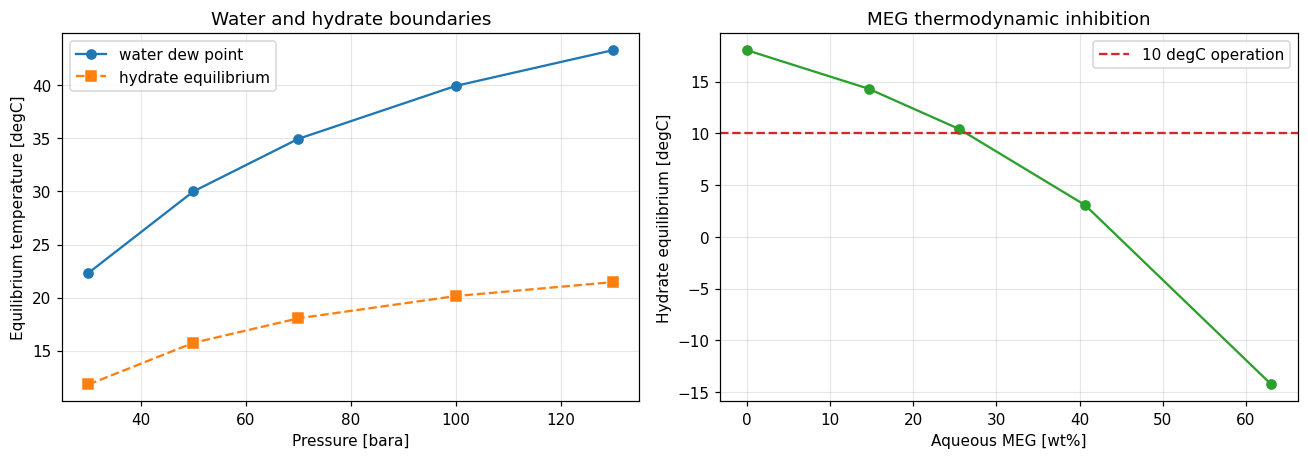

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(dew_point_table["pressure [bara]"], dew_point_table["water dew point [degC]"], "o-", label="water dew point")
axes[0].plot(hydrate_table["pressure [bara]"], hydrate_table["hydrate equilibrium [degC]"], "s--", label="hydrate equilibrium")
axes[0].set(xlabel="Pressure [bara]", ylabel="Equilibrium temperature [degC]", title="Water and hydrate boundaries")
axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].plot(meg_table["aqueous MEG [wt%]"], meg_table["hydrate equilibrium [degC]"], "o-", color="tab:green")
axes[1].axhline(basis["cooler_outlet_C"], color="tab:red", linestyle="--", label="10 degC operation")
axes[1].set(xlabel="Aqueous MEG [wt%]", ylabel="Hydrate equilibrium [degC]", title="MEG thermodynamic inhibition")
axes[1].grid(True, alpha=0.3); axes[1].legend()
fig.tight_layout(); plt.show()

## Verification and troubleshooting

The assertions check composition, the saturation/dew-point limiting case, mass and water closure, phase routing, cooler sign, brine trend, hydrate trend, inhibitor response, dosing algebra, and rate scaling. If execution fails, check exact component names and units, use CPA mixing rule 10 for water/MEG cases, enable multiphase checking, and run each process after changing inputs. Hydrate calculations need a water component and may take longer than a TP flash.

In [16]:
checks = {
    "dry-gas composition closes": abs(sum(dry_gas_composition.values())-1.0) < 1e-12,
    "saturated water is finite and positive": np.isfinite(water_ppm_mol) and water_ppm_mol > 0.0,
    "70-bara dew point reproduces saturation temperature": abs(float(dew_point_table.loc[dew_point_table["pressure [bara]"]==70.0, "water dew point [degC]"].iloc[0])-35.0) < 0.2,
    "cooling increases aqueous water": cooling_table["aqueous water [kg/h]"].iloc[-1] > cooling_table["aqueous water [kg/h]"].iloc[1] > 0.0,
    "total process mass closes": abs(total_mass_residual) < 1e-9,
    "water component closes": abs(water_mass_residual) < 1e-9,
    "knock-out liquid is water rich": process_results["liquid water mass fraction [-]"] > 0.99,
    "cooler removes heat": production_cooler.getDuty() < 0.0,
    "moderate brine density rises with salinity": brine_table["aqueous density [kg/m3]"].is_monotonic_increasing,
    "hydrate equilibrium rises with pressure": hydrate_table["hydrate equilibrium [degC]"].is_monotonic_increasing,
    "MEG lowers hydrate equilibrium": meg_table["hydrate equilibrium [degC]"].is_monotonic_decreasing,
    "dosing algebra recovers targets": np.max(np.abs(dosing_table["target MEG [wt%]"]-dosing_table["recalculated MEG [wt%]"])) < 1e-10,
    "specific condensed water is rate invariant": rate_table["specific condensed water [kg/t gas]"].std()/rate_table["specific condensed water [kg/t gas]"].mean() < 1e-6,
}
for name, passed in checks.items(): print(f"{'PASS' if passed else 'FAIL'}  {name}")
assert all(checks.values()), [name for name, passed in checks.items() if not passed]
print(f"All {len(checks)} engineering checks passed.")

PASS  dry-gas composition closes
PASS  saturated water is finite and positive
PASS  70-bara dew point reproduces saturation temperature
PASS  cooling increases aqueous water
PASS  total process mass closes
PASS  water component closes
PASS  knock-out liquid is water rich
PASS  cooler removes heat
PASS  moderate brine density rises with salinity
PASS  hydrate equilibrium rises with pressure
PASS  MEG lowers hydrate equilibrium
PASS  dosing algebra recovers targets
PASS  specific condensed water is rate invariant
All 13 engineering checks passed.


## Summary, exercises, and references

You connected CPA water thermodynamics to a cooler/separator water-management process, added a moderate-NaCl property screen, calculated hydrate equilibrium and MEG inhibition, and verified balances and trends. Exercises: use a measured gas and water analysis; add a three-phase inlet separator; test a cold depressurization path; couple MEG injection and regeneration; add equipment capacity limits; and compare predictions with qualified laboratory or field data.

References: [NeqSim documentation](https://equinor.github.io/neqsimhome/); Sloan and Koh, *Clathrate Hydrates of Natural Gases*, 3rd ed.; GPSA Engineering Data Book sections on water content, dehydration, and hydrates; and ASTM D1141 for substitute ocean-water composition. Use the governing project standards and validated chemical/property data.

In [17]:
result_record = {
    "neqsim_version": NEQSIM_VERSION,
    "water_saturated_gas_mol_ppm": round(water_ppm_mol, 3),
    "water_knocked_out_kg_per_h": round(liquid_water_out, 4),
    "uninhibited_hydrate_equilibrium_C_at_70_bara": round(hydrate_equilibrium_70_C, 3),
    "cooler_duty_MW": round(production_cooler.getDuty()/1e6, 5),
    "validated_checks": len(checks),
    "important_limit": "corrosion, scale, reaction chemistry, kinetics, and treatment design are outside this screen"
}
print(json.dumps(result_record, indent=2))

{
  "neqsim_version": "3.16.0",
  "water_saturated_gas_mol_ppm": 1013.862,
  "water_knocked_out_kg_per_h": 7.3069,
  "uninhibited_hydrate_equilibrium_C_at_70_bara": 18.044,
  "cooler_duty_MW": -0.19344,
  "validated_checks": 13,
  "important_limit": "corrosion, scale, reaction chemistry, kinetics, and treatment design are outside this screen"
}
